k     = 0.2415
V_C   = 845.5 ft/s
V_D   = 1056.9 ft/s
q_max = 1327.5 lb/ft^2



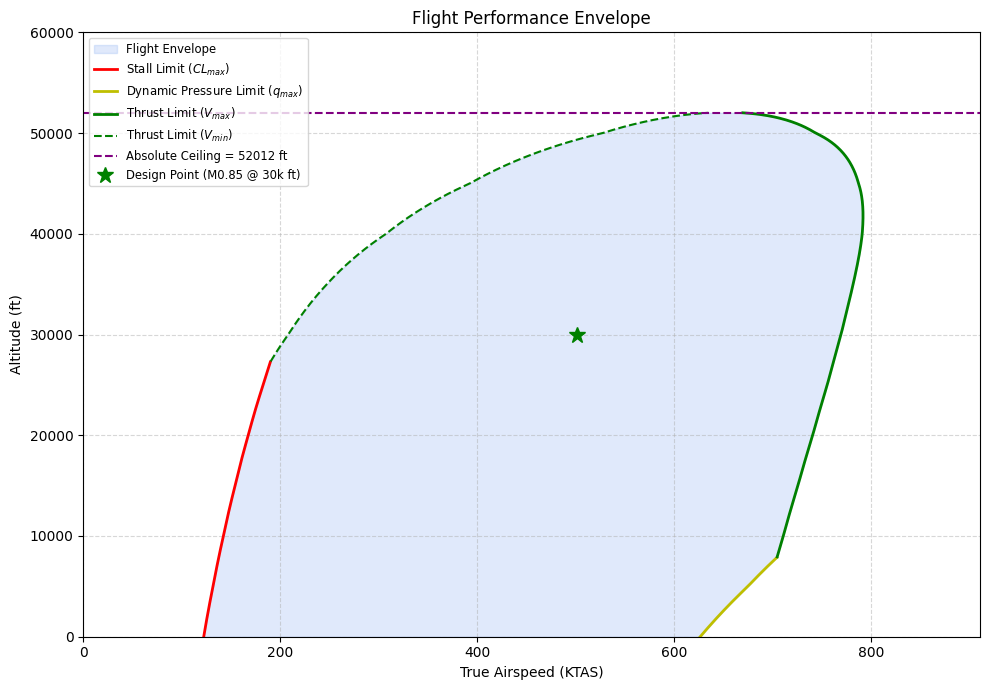

In [6]:
import numpy as np
import matplotlib.pyplot as plt

## ── AIRCRAFT PARAMETERS ──────────────────────────────────────────────────────
W     = 54748.1
S     = 600.0
CLmax = 1.8
M_max = 1.6
n_eng = 1
T_SL  = 46800.0
CD0   = 0.04871
AR    = 2.02758
e     = 0.65
k     = 1 / (np.pi * e * AR)

## ── ATMOSPHERE TABLE ─────────────────────────────────────────────────────────
alt_tb = np.array([0, 5000, 10000, 15000, 20000, 25000, 30000, 35000, 40000, 45000, 50000, 60000])
rho_tb = np.array([23.77, 20.48, 17.56, 14.96, 12.67, 10.66, 8.91, 7.38, 5.87, 4.62, 3.64, 2.24]) * 1e-4
T_tb   = np.array([518.67, 500.84, 483.03, 465.22, 447.41, 429.62, 411.84, 394.06, 389.97, 389.97, 389.97, 389.97])
P_tb   = np.array([2116.2, 1760.9, 1455.3, 1194.8, 972.2, 785.3, 628.4, 498.0, 391.8, 308.0, 242.2, 151.0])

## ── CONSTANTS ────────────────────────────────────────────────────────────────
rho0 = 23.77e-4
P0   = 2116.2
gam  = 1.4
R    = 1716.0

## ── DERIVED ──────────────────────────────────────────────────────────────────
T_30k = -47.83 + 459.67
a_30k = np.sqrt(gam * R * T_30k)
V_C   = 0.85 * a_30k
V_D   = 1.25 * V_C
q_max = 0.5 * rho0 * V_D**2

print(f"k     = {k:.4f}")
print(f"V_C   = {V_C:.1f} ft/s")
print(f"V_D   = {V_D:.1f} ft/s")
print(f"q_max = {q_max:.1f} lb/ft^2\n")

## ── ALTITUDE SWEEP ───────────────────────────────────────────────────────────
h = np.linspace(0, 60000, 1000)
rho = np.interp(h, alt_tb, rho_tb)
T_R = np.interp(h, alt_tb, T_tb)
P   = np.interp(h, alt_tb, P_tb)
sigma = rho / rho0
a     = np.sqrt(gam * R * T_R)

def fps2ktas(v):
    return v * 0.592484

## ── 1. STALL ─────────────────────────────────────────────────────────────────
V_stall_fps  = np.sqrt((2 / (rho0 * sigma)) * (W/S) / CLmax)
V_stall_ktas = fps2ktas(V_stall_fps)

## ── 2. STRUCTURAL LIMIT ──────────────────────────────────────────────────────
V_struct_fps  = np.sqrt(2 * q_max / rho)
V_struct_ktas = fps2ktas(V_struct_fps)

## ── 3. THRUST LIMITS ─────────────────────────────────────────────────────────
n_lapse = 0.7
T_A = T_SL * (sigma**n_lapse)

V_thrust_max = np.full_like(h, np.nan)
V_thrust_min = np.full_like(h, np.nan)

A_coeff = 0.5 * rho * S * CD0
B_coeff = -T_A
C_coeff = (2 * k * W**2) / (rho * S)
disc = B_coeff**2 - 4 * A_coeff * C_coeff

mask = disc >= 0
V2_pos = (-B_coeff[mask] + np.sqrt(disc[mask])) / (2 * A_coeff[mask])
V2_neg = (-B_coeff[mask] - np.sqrt(disc[mask])) / (2 * A_coeff[mask])

V_thrust_max[mask] = fps2ktas(np.sqrt(V2_pos))
V_thrust_min[mask] = fps2ktas(np.sqrt(V2_neg))

## ── ABSOLUTE CEILING ─────────────────────────────────────────────────────────
ceiling_indices = np.where(~np.isnan(V_thrust_max))[0]
ceiling_idx = ceiling_indices[-1] if ceiling_indices.size > 0 else 0
ceiling_alt = h[ceiling_idx]

## ── ENVELOPE BOUNDARIES ──────────────────────────────────────────────────────
h_v       = h[:ceiling_idx+1]
V_stall_v = V_stall_ktas[:ceiling_idx+1]
V_struct_v = V_struct_ktas[:ceiling_idx+1]
V_tmax_v  = V_thrust_max[:ceiling_idx+1]
V_tmin_v  = V_thrust_min[:ceiling_idx+1]

V_tmin_clean = np.where(np.isnan(V_tmin_v), V_stall_v, V_tmin_v)
V_left  = np.maximum(V_stall_v, V_tmin_clean)
V_right = np.minimum(V_struct_v, V_tmax_v)

good = V_left < V_right

## ── PLOT ─────────────────────────────────────────────────────────────────────
plt.figure(figsize=(10, 7), facecolor='white')
plt.grid(True, which='both', linestyle='--', alpha=0.5)

# Shaded envelope
plt.fill_betweenx(h_v[good], V_left[good], V_right[good],
                  color='cornflowerblue', alpha=0.2, label='Flight Envelope')

# Stall — left boundary where stall is more restrictive than thrust min
stall_mask = V_stall_v >= V_tmin_clean
plt.plot(V_stall_v[stall_mask], h_v[stall_mask],
         'r-', linewidth=2, label='Stall Limit ($CL_{max}$)')

# Structural — right boundary only where it's tighter than thrust max
struct_mask = V_struct_v <= V_tmax_v
plt.plot(V_struct_v[struct_mask], h_v[struct_mask],
         'y-', linewidth=2, label='Dynamic Pressure Limit ($q_{max}$)')

# Thrust max — right boundary where structural isn't active
tmax_mask = V_tmax_v <= V_struct_v
plt.plot(V_tmax_v[tmax_mask], h_v[tmax_mask],
         'g-', linewidth=2, label='Thrust Limit ($V_{max}$)')

# Thrust min — left boundary where it's more restrictive than stall
tmin_mask = ~np.isnan(V_tmin_v) & (V_tmin_v >= V_stall_v)
plt.plot(V_tmin_v[tmin_mask], h_v[tmin_mask],
         'g--', linewidth=1.5, label='Thrust Limit ($V_{min}$)')

# Absolute ceiling
plt.axhline(ceiling_alt, color='purple', linestyle='--', linewidth=1.5,
            label=f'Absolute Ceiling = {ceiling_alt:.0f} ft')

# Cruise point
V_cruise_ktas = fps2ktas(V_C)
plt.plot(V_cruise_ktas, 30000, 'g*', markersize=12, label='Design Point (M0.85 @ 30k ft)')

plt.xlabel('True Airspeed (KTAS)')
plt.ylabel('Altitude (ft)')
plt.title('Flight Performance Envelope')
plt.legend(loc='upper left', fontsize='small')
plt.xlim(0, np.max(V_right[good]) * 1.15)
plt.ylim(0, 60000)
plt.tight_layout()
plt.show()